# 13 — FPCA experiment: results exploration and visualisation

Loads outputs from **`12_fpca_classifier.py`** (`results/fpca_*.csv`, figures). Use this notebook for extra plots, tables, and thesis figures without re-running the full CV loop.

Sections **2–3** plot PR-AUC, ROC-AUC, precision, sensitivity, F1, and Youden J vs **J** (with focused SVM baselines). **4** shows per-fold histograms for a chosen classifier/J.

**Run first:** `python 12_fpca_classifier.py` (from `transformation_experiment/` or with `data/` visible).


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EXPERIMENT_DIR = Path.cwd() if Path("data").exists() else Path("transformation_experiment")
DATA_DIR = EXPERIMENT_DIR / "data"
RESULTS_DIR = EXPERIMENT_DIR / "results"
POC_DIR = Path("transformation_poc") if Path("transformation_poc").exists() else Path("..") / "transformation_poc"

print(RESULTS_DIR.resolve())


/Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results


## 1. Summary tables


In [2]:
df_sum_fpca = pd.read_csv(RESULTS_DIR / "fpca_classifier_summary.csv")
df_table = pd.read_csv(RESULTS_DIR / "fpca_vs_baselines_table.csv")
# Per-fold: pr_auc, roc_auc, sensitivity, precision, specificity, accuracy, f1, youden_j, youden_threshold
df_long = pd.read_csv(RESULTS_DIR / "fpca_classifier_rskf_metrics.csv")

display(df_table)
print("Per-J summary (head):")
display(df_sum_fpca.head(12))


,Method,Representation,K or J,PR-AUC mean ± std,ROC-AUC mean ± std,Sensitivity mean ± std,Precision mean ± std,F1 mean ± std,Youden J mean ± std
0,Chebyshev + SVM,Fixed polynomial,5,0.8750 ± 0.0047,0.9274 ± 0.0016,0.8335 ± 0.0049,0.7915 ± 0.0105,0.8112 ± 0.0056,0.7785 ± 0.0052
1,Legendre + SVM,Fixed polynomial,50,0.8504 ± 0.0079,0.9119 ± 0.0037,0.8151 ± 0.0096,0.7337 ± 0.0376,0.7699 ± 0.0209,0.7391 ± 0.0165
2,Native XP + SVM,Hermite / BP+RP coeffs,110,0.8805 ± 0.0038,0.9386 ± 0.0017,0.8419 ± 0.0131,0.7631 ± 0.0223,0.7995 ± 0.0088,0.7762 ± 0.0078
3,FPCA + Centroid,Data-adaptive (FPCA),20,0.3000 ± 0.0263,0.6498 ± 0.0239,0.8665 ± 0.0306,0.2600 ± 0.0092,0.3999 ± 0.0131,0.2564 ± 0.0343
4,FPCA + LR,Data-adaptive (FPCA),30,0.5613 ± 0.0467,0.8070 ± 0.0216,0.6662 ± 0.0891,0.4485 ± 0.0727,0.5264 ± 0.0327,0.4492 ± 0.0420
5,FPCA + SVM,Data-adaptive (FPCA),30,0.6702 ± 0.0387,0.8648 ± 0.0184,0.8692 ± 0.0343,0.4206 ± 0.0255,0.5661 ± 0.0233,0.5713 ± 0.0366


Per-J summary (head):


,J,classifier,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,sensitivity_mean,sensitivity_std,precision_mean,precision_std,specificity_mean,specificity_std,accuracy_mean,accuracy_std,f1_mean,f1_std,youden_j_mean,youden_j_std,youden_threshold_mean,youden_threshold_std
0,1,centroid,0.288161,0.024484,0.631018,0.022672,0.829194,0.027741,0.255965,0.009483,0.403682,0.022008,0.488028,0.018180,0.391113,0.013240,0.232876,0.034117,0.010050,0.000000
1,1,lr,0.288161,0.024484,0.631018,0.022672,0.829194,0.027741,0.255965,0.009483,0.403682,0.022008,0.488028,0.018180,0.391113,0.013240,0.232876,0.034117,0.010050,0.000000
2,1,svm,0.263320,0.024919,0.622286,0.024029,0.842440,0.030935,0.254399,0.008194,0.389323,0.021983,0.479147,0.016579,0.390721,0.011949,0.231764,0.031086,0.049045,0.006927
3,2,centroid,0.295507,0.025516,0.641908,0.024173,0.848742,0.033270,0.253862,0.008029,0.382905,0.026694,0.475240,0.018890,0.390721,0.011363,0.231647,0.029610,0.080302,0.009442
4,2,lr,0.405465,0.037564,0.738392,0.023898,0.677075,0.050165,0.348892,0.024332,0.685783,0.035999,0.684050,0.025568,0.459573,0.025262,0.362858,0.045443,0.387136,0.020606
5,2,svm,0.394568,0.035363,0.735780,0.024099,0.691583,0.054187,0.340590,0.021822,0.667662,0.034367,0.672398,0.023507,0.455588,0.024850,0.359245,0.045720,0.511759,0.021971
6,3,centroid,0.299830,0.026261,0.649469,0.023895,0.865935,0.031118,0.259974,0.009314,0.390256,0.022188,0.484547,0.017957,0.399825,0.013381,0.256191,0.035217,0.073668,0.007639
7,3,lr,0.550248,0.046031,0.802815,0.021711,0.657386,0.085140,0.440993,0.065982,0.781756,0.073543,0.757087,0.045387,0.519841,0.032440,0.439142,0.044240,0.407839,0.023358
8,3,svm,0.599930,0.043936,0.839434,0.019245,0.752363,0.061487,0.427833,0.042741,0.744847,0.060404,0.746323,0.040240,0.542304,0.030717,0.497210,0.043865,0.321206,0.047552
9,5,centroid,0.299831,0.026263,0.649468,0.023920,0.866115,0.030978,0.260043,0.009264,0.390345,0.022294,0.484654,0.017978,0.399926,0.013290,0.256460,0.034993,0.073668,0.007639


## 2. PR-AUC vs J (from summary CSV)


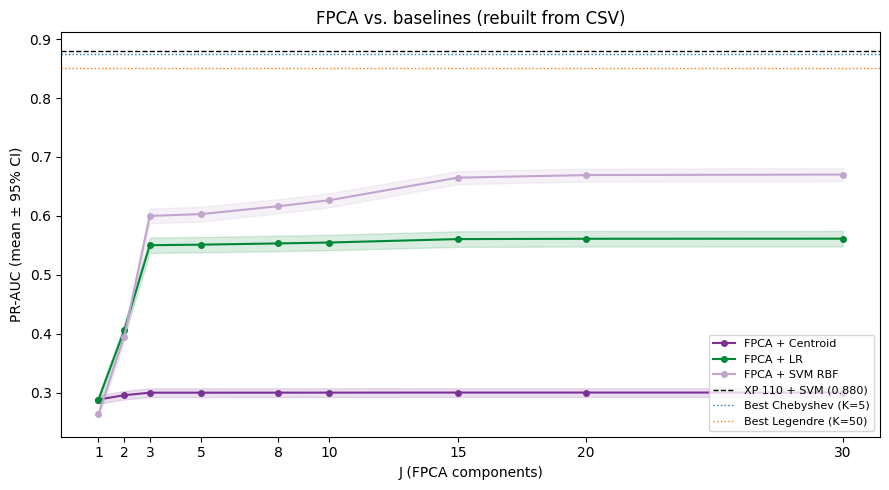

In [3]:
from scipy import stats as _stats

N_SPLITS = 50  # 10 repeats × 5 folds
_t_crit = _stats.t.ppf(0.975, N_SPLITS - 1)

J_ORDER = sorted(df_sum_fpca["J"].unique())
fig, ax = plt.subplots(figsize=(9, 5))
for clf, color, lab in [
    ("centroid", "#7b3294", "FPCA + Centroid"),
    ("lr", "#008837", "FPCA + LR"),
    ("svm", "#c2a5cf", "FPCA + SVM RBF"),
]:
    sub = df_sum_fpca[df_sum_fpca["classifier"] == clf].set_index("J")
    js_available = [j for j in J_ORDER if j in sub.index]
    if not js_available:
        continue
    m = sub.loc[js_available, "pr_auc_mean"]
    s = sub.loc[js_available, "pr_auc_std"]
    ci_half = _t_crit * s / np.sqrt(N_SPLITS)
    ax.plot(js_available, m, "o-", color=color, label=lab, ms=4)
    ax.fill_between(
        js_available,
        m - ci_half,
        m + ci_half,
        color=color,
        alpha=0.15,
    )

df_base = pd.read_csv(RESULTS_DIR / "focused_summary.csv")
def best_svm(mask):
    r = df_base.loc[mask].sort_values("pr_auc_mean", ascending=False).iloc[0]
    return r["pr_auc_mean"], int(r["n_features"]), r["representation"]

m_xp, _, _ = best_svm((df_base["representation"] == "og_xp_110") & (df_base["classifier"] == "SVM_RBF"))
m_ch, k_ch, n_ch = best_svm(
    df_base["representation"].str.startswith("chebyshev")
    & df_base["representation"].str.endswith("_L2")
    & (df_base["classifier"] == "SVM_RBF")
)
m_leg, k_leg, n_leg = best_svm(
    df_base["representation"].str.startswith("legendre")
    & df_base["representation"].str.endswith("_L2")
    & (df_base["classifier"] == "SVM_RBF")
)

ax.axhline(m_xp, color="black", ls="--", lw=1, label=f"XP 110 + SVM ({m_xp:.3f})")
ax.axhline(m_ch, color="tab:blue", ls=":", lw=1, label=f"Best Chebyshev (K={k_ch})")
ax.axhline(m_leg, color="tab:orange", ls=":", lw=1, label=f"Best Legendre (K={k_leg})")

ax.set_xlabel("J (FPCA components)")
ax.set_ylabel("PR-AUC (mean ± 95% CI)")
ax.set_title("FPCA vs. baselines (rebuilt from CSV)")
ax.legend(loc="lower right", fontsize=8)
ax.set_xticks(J_ORDER)
fig.tight_layout()
plt.show()

## 3. ROC-AUC, precision, F1, sensitivity, Youden J vs J

Same layout as §2: FPCA curves (mean ± 1 SD) and focused-experiment SVM baselines (Chebyshev / Legendre / native XP). Thresholded metrics use the Youden rule on training scores as in `12_fpca_classifier.py`.


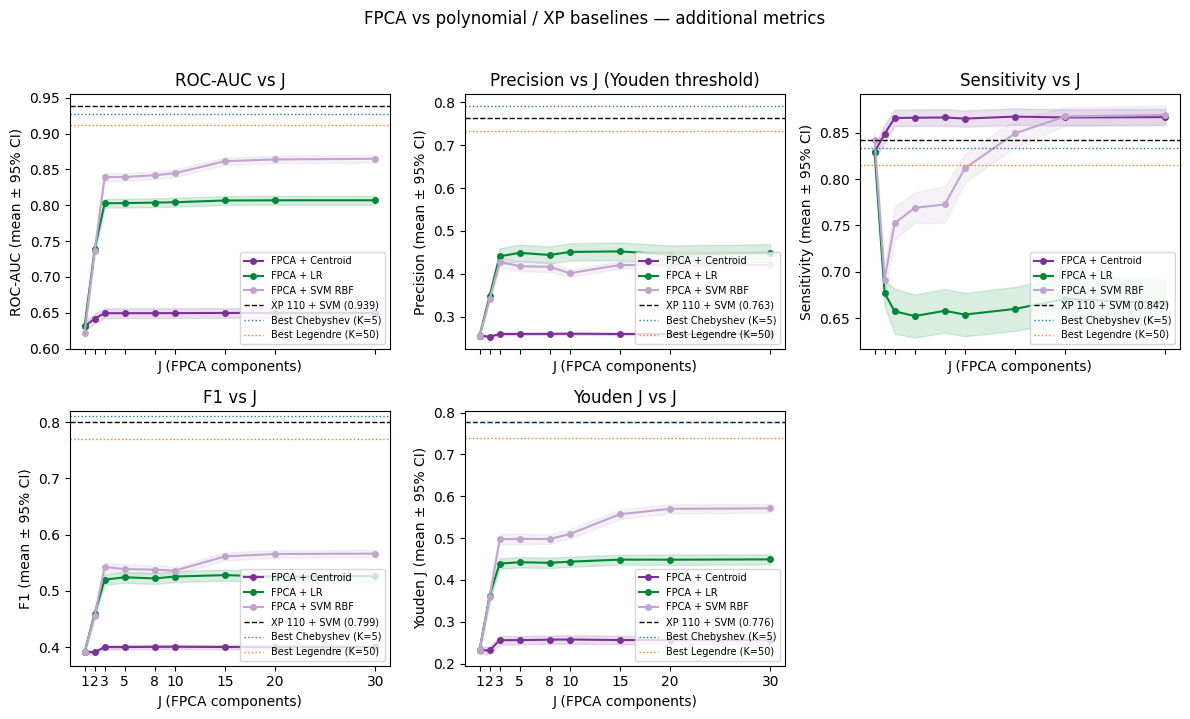

In [4]:
# Focused baselines: same three SVM rows as §2 (by PR-AUC on focused_summary)

# J_ORDER might have values that are not an index in [set_index("J")]. To avoid KeyError,
# we should only use J values that are both in J_ORDER and in the DataFrame for each classifier.
J_ORDER = sorted(df_sum_fpca["J"].unique())
df_base = pd.read_csv(RESULTS_DIR / "focused_summary.csv")

def baseline_svm_rows():
    def pick(mask):
        return df_base.loc[mask].sort_values("pr_auc_mean", ascending=False).iloc[0]
    m_xp = pick(
        (df_base["representation"] == "og_xp_110") & (df_base["classifier"] == "SVM_RBF")
    )
    m_ch = pick(
        df_base["representation"].str.startswith("chebyshev")
        & df_base["representation"].str.endswith("_L2")
        & (df_base["classifier"] == "SVM_RBF")
    )
    m_leg = pick(
        df_base["representation"].str.startswith("legendre")
        & df_base["representation"].str.endswith("_L2")
        & (df_base["classifier"] == "SVM_RBF")
    )
    k_ch, k_leg = int(m_ch["n_features"]), int(m_leg["n_features"])
    return m_xp, m_ch, m_leg, k_ch, k_leg

m_xp_b, m_ch_b, m_leg_b, k_ch_b, k_leg_b = baseline_svm_rows()

CLF_STYLE = [
    ("centroid", "#7b3294", "FPCA + Centroid"),
    ("lr", "#008837", "FPCA + LR"),
    ("svm", "#c2a5cf", "FPCA + SVM RBF"),
]

def plot_metric_vs_j(ax, col: str, ylabel: str, title: str):
    """col = e.g. 'roc_auc' -> uses {col}_mean, {col}_std from df_sum_fpca."""
    mcol, scol = f"{col}_mean", f"{col}_std"
    for clf, color, lab in CLF_STYLE:
        sub = df_sum_fpca[df_sum_fpca["classifier"] == clf].set_index("J")
        js_available = [j for j in J_ORDER if j in sub.index]
        if not js_available:
            continue
        sub_plot = sub.loc[js_available]
        ci_half = _t_crit * sub_plot[scol] / np.sqrt(N_SPLITS)
        ax.plot(js_available, sub_plot[mcol], "o-", color=color, label=lab, ms=4)
        ax.fill_between(
            js_available,
            sub_plot[mcol] - ci_half,
            sub_plot[mcol] + ci_half,
            color=color,
            alpha=0.15,
        )
    ax.axhline(
        m_xp_b[f"{col}_mean"],
        color="black",
        ls="--",
        lw=1,
        label=f"XP 110 + SVM ({m_xp_b[f'{col}_mean']:.3f})",
    )
    ax.axhline(
        m_ch_b[f"{col}_mean"],
        color="tab:blue",
        ls=":",
        lw=1,
        label=f"Best Chebyshev (K={k_ch_b})",
    )
    ax.axhline(
        m_leg_b[f"{col}_mean"],
        color="tab:orange",
        ls=":",
        lw=1,
        label=f"Best Legendre (K={k_leg_b})",
    )
    ax.set_xlabel("J (FPCA components)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=7)
    ax.set_xticks(J_ORDER)

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True)
axes = axes.ravel()
panels = [
    ("roc_auc", "ROC-AUC (mean ± 95% CI)", "ROC-AUC vs J"),
    ("precision", "Precision (mean ± 95% CI)", "Precision vs J (Youden threshold)"),
    ("sensitivity", "Sensitivity (mean ± 95% CI)", "Sensitivity vs J"),
    ("f1", "F1 (mean ± 95% CI)", "F1 vs J"),
    ("youden_j", "Youden J (mean ± 95% CI)", "Youden J vs J"),
]
for ax, (col, ylab, ttl) in zip(axes[:5], panels):
    plot_metric_vs_j(ax, col, ylab, ttl)
axes[5].set_visible(False)
fig.suptitle("FPCA vs polynomial / XP baselines — additional metrics", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

## 4. Fold-level distributions (example: SVM at largest J)

Histograms use per-fold values from `df_long`. Change `J_pick` / `classifier` to explore other settings.


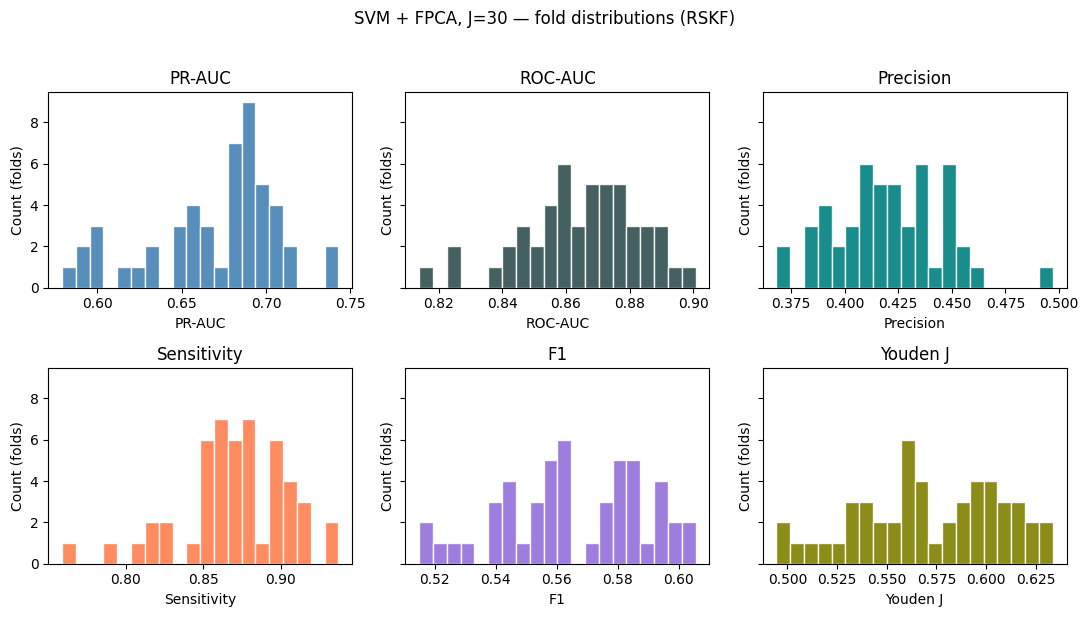

In [5]:
J_pick = int(df_long.loc[df_long["classifier"] == "svm", "J"].max())
sub = df_long[(df_long["classifier"] == "svm") & (df_long["J"] == J_pick)]

hist_cols = [
    ("pr_auc", "PR-AUC", "steelblue"),
    ("roc_auc", "ROC-AUC", "darkslategray"),
    ("precision", "Precision", "teal"),
    ("sensitivity", "Sensitivity", "coral"),
    ("f1", "F1", "mediumpurple"),
    ("youden_j", "Youden J", "olive"),
]
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharey=True)
axes = axes.ravel()
for ax, (col, lab, c) in zip(axes, hist_cols):
    ax.hist(sub[col].dropna(), bins=20, color=c, edgecolor="white", alpha=0.9)
    ax.set_xlabel(lab)
    ax.set_ylabel("Count (folds)")
    ax.set_title(lab)
fig.suptitle(f"SVM + FPCA, J={J_pick} — fold distributions (RSKF)", y=1.02)
fig.tight_layout()
plt.show()


## 5. Optional — reload spectra for extra plots

Same merge as in `12_fpca_classifier.py` (labels from `og_xp`, flux from `xp_sampled_spectra`; **no** XP coefficients as features).


In [6]:
df_og = pd.read_csv(DATA_DIR / "og_xp.csv")
df_spec = pd.read_csv(POC_DIR / "xp_sampled_spectra.csv")
wl_cols = [c for c in df_spec.columns if c.startswith("wl_")]
wavelengths = np.array([float(c.split("_")[1]) for c in wl_cols], dtype=np.float64)

df_m = df_og[["source_id", "y"]].merge(
    df_spec[["source_id"] + wl_cols], on="source_id", how="inner", validate="one_to_one"
)
y = df_m["y"].to_numpy(dtype=np.int64)
F_raw = df_m[wl_cols].to_numpy(dtype=np.float64)
F = F_raw / np.maximum(np.linalg.norm(F_raw, axis=1, keepdims=True), 1e-15)
print("Reloaded F shape:", F.shape)


Reloaded F shape: (2815, 343)
